# PCA + Regression/SVR Notebook (Flooding, Infrastructure, School Outcomes)

This notebook:
1. Loads the dataset
2. Cleans key columns (percent-to-numeric + missing-value rules)
3. Runs PCA separately for flood and infrastructure feature sets
4. Produces scree plots and loading plots
5. Runs Linear Regression and SVR for:
   - Absence rate
   - Attainment score
   - Year-on-year attainment


In [1]:
# ==============================
# Imports & settings
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error


In [2]:
# ==============================
# 1) Load data
# ==============================

df = pd.read_csv("Master Data(08_02_2026).csv")
print("Loaded df shape:", df.shape)

# Quick peek
display(df.head())


Loaded df shape: (1319, 22)


,Area,Ward,Number of schools,School,School URN,Year,Catchment area km2,Total road length in catchment,% of minor roads,Avg elevation,...,% of road length flooded at least once,Max flood duration,School population,Absence rate,Persistent absence,Avg lateness,School closure occured,Attainment score,Year-on-year attainment,YY value
0,Calderdale,NaN,NaN,Abbey Park Academy,140172.0,2018,18.9596,15.61,76.3,NaN,...,NaN,NaN,216.0,4.4,8.9,NaN,NaN,73%,17.74%,17.74%
1,Calderdale,NaN,NaN,Abbey Park Academy,140172.0,2015,18.9596,15.61,76.3,NaN,...,NaN,NaN,214.0,4.8,4.3,NaN,NaN,84%,NaN,NaN
2,Calderdale,NaN,NaN,Abbey Park Academy,140172.0,2016,18.9596,15.61,76.3,NaN,...,NaN,NaN,223.0,4.4,13.5,NaN,NaN,32%,-61.90%,-61.90%
3,Calderdale,NaN,NaN,Abbey Park Academy,140172.0,2017,18.9596,15.61,76.3,NaN,...,NaN,NaN,213.0,4.0,7.3,NaN,NaN,62%,93.75%,93.75%
4,Calderdale,NaN,NaN,Abbey Park Academy,140172.0,2019,18.9596,15.61,76.3,NaN,...,NaN,NaN,215.0,4.1,10.5,NaN,NaN,60%,-17.81%,-17.81%


## 2) Data cleaning

### Rules requested
- Convert percentage-like columns to numeric (e.g., `"79%"` → `79.0`)
- Flood variables:
  - `% of catchment in flood-risk zone`: missing → **0**
  - `Road flood days per year`: missing → **0**
  - `% of road length flooded at least once`: **drop rows where missing**
- Infrastructure variables:
  - Drop rows missing any of: `Catchment area km2`, `Total road length in catchment`, `% of minor roads`
- Print dataset shape after each major step


In [3]:
# ==============================
# 2) Data cleaning
# ==============================

df_clean = df.copy()
print("Start shape:", df_clean.shape)

# ----------
# 2A) Convert percentage-like columns to numeric
#    - Any column name containing '%' is treated as percent-like
#    - Also convert known outcome columns if they contain percent strings
# ----------
percent_like_cols = [c for c in df_clean.columns if "%" in c] + [
    "Absence rate",
    "Persistent absence",
    "Attainment score",
    "Year-on-year attainment",
    "YY value",
]

percent_like_cols = [c for c in dict.fromkeys(percent_like_cols) if c in df_clean.columns]  # unique, existing only

for col in percent_like_cols:
    # Strip % and whitespace, coerce errors to NaN
    df_clean[col] = (
        df_clean[col]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.strip()
        .replace({"": np.nan, "nan": np.nan, "None": np.nan, "N/A": np.nan, "NA": np.nan, "-": np.nan, "—": np.nan})
    )
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

print("After percent-to-numeric conversion:", df_clean.shape)

# ----------
# 2B) Apply missing-data rules for flood variables
# ----------
flood_features = [
    "% of catchment in flood-risk zone",
    "Road flood days per year",
    "% of road length flooded at least once"
]

# Coerce flood columns to numeric (safe even if already numeric)
for col in flood_features:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Fill missing catchment flood-risk zone with 0
df_clean["% of road length flooded at least once"] = df_clean["% of catchment in flood-risk zone"].fillna(0)

# Fill missing flood days with 0
df_clean["Road flood days per year"] = df_clean["Road flood days per year"].fillna(0)

# Drop rows missing "% of road length flooded at least once"
before = df_clean.shape[0]
df_clean = df_clean.dropna(subset=["% of catchment in flood-risk zone"])
after = df_clean.shape[0]
print(f"After dropping missing '% of catchment in flood-risk zone': {df_clean.shape} (dropped {before-after} rows)")

# ----------
# 2C) Apply missing-data rules for infrastructure variables
# ----------
infra_features = [
    "Catchment area km2",
    "Total road length in catchment",
    "% of minor roads"
]

# Coerce infra columns to numeric
for col in infra_features:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

before = df_clean.shape[0]
df_clean = df_clean.dropna(subset=infra_features)
after = df_clean.shape[0]
print(f"After dropping missing infra vars: {df_clean.shape} (dropped {before-after} rows)")

# Final check
print("Final cleaned shape:", df_clean.shape)
display(df_clean.head())


Start shape: (1319, 22)
After percent-to-numeric conversion: (1319, 22)
After dropping missing '% of catchment in flood-risk zone': (724, 22) (dropped 595 rows)
After dropping missing infra vars: (642, 22) (dropped 82 rows)
Final cleaned shape: (642, 22)


,Area,Ward,Number of schools,School,School URN,Year,Catchment area km2,Total road length in catchment,% of minor roads,Avg elevation,...,% of road length flooded at least once,Max flood duration,School population,Absence rate,Persistent absence,Avg lateness,School closure occured,Attainment score,Year-on-year attainment,YY value
0,Calderdale,NaN,NaN,Abbey Park Academy,140172.0,2018,18.9596,15.61,76.3,NaN,...,1.689994,NaN,216.0,4.4,8.9,NaN,NaN,73.0,17.74,17.74
1,Calderdale,NaN,NaN,Abbey Park Academy,140172.0,2015,18.9596,15.61,76.3,NaN,...,1.689994,NaN,214.0,4.8,4.3,NaN,NaN,84.0,NaN,NaN
2,Calderdale,NaN,NaN,Abbey Park Academy,140172.0,2016,18.9596,15.61,76.3,NaN,...,1.689994,NaN,223.0,4.4,13.5,NaN,NaN,32.0,-61.90,-61.90
3,Calderdale,NaN,NaN,Abbey Park Academy,140172.0,2017,18.9596,15.61,76.3,NaN,...,1.689994,NaN,213.0,4.0,7.3,NaN,NaN,62.0,93.75,93.75
4,Calderdale,NaN,NaN,Abbey Park Academy,140172.0,2019,18.9596,15.61,76.3,NaN,...,1.689994,NaN,215.0,4.1,10.5,NaN,NaN,60.0,-17.81,-17.81


## 3) PCA (separate for Flood and Infrastructure)

We standardise each feature group and fit PCA.
We keep **2 components** for each group to:
- enable 2D visualisation
- reduce dimensionality for modelling
- keep interpretation manageable

Next: scree plots (explained variance) + loading plots (variable contributions).


In [15]:
# ==============================
# 3) PCA
# ==============================

# ==============================
# Flood PCA (diagnostic – full components)
# ==============================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

flood_data = df_clean[flood_features].dropna()

scaler_flood = StandardScaler()
flood_scaled = scaler_flood.fit_transform(flood_data)

# Keep ALL components for scree/loadings
flood_pca_full = PCA()
flood_pcs_full = flood_pca_full.fit_transform(flood_scaled)

# --- Infra PCA
# ==============================
# Infrastructure PCA (diagnostic – full components)
# ==============================

infra_data = df_clean[infra_features].dropna()

scaler_infra = StandardScaler()
infra_scaled = scaler_infra.fit_transform(infra_data)

infra_pca_full = PCA()
infra_pcs_full = infra_pca_full.fit_transform(infra_scaled)

print(

## 4) PCA plots

### Scree plots
Show explained variance ratio per component.

### Loading plots
Show how much each original variable contributes to each PC (sign indicates direction).


[6.66680320e-01 3.33319680e-01 7.38995804e-17]
[0.61543552 0.25134228 0.1332222 ]


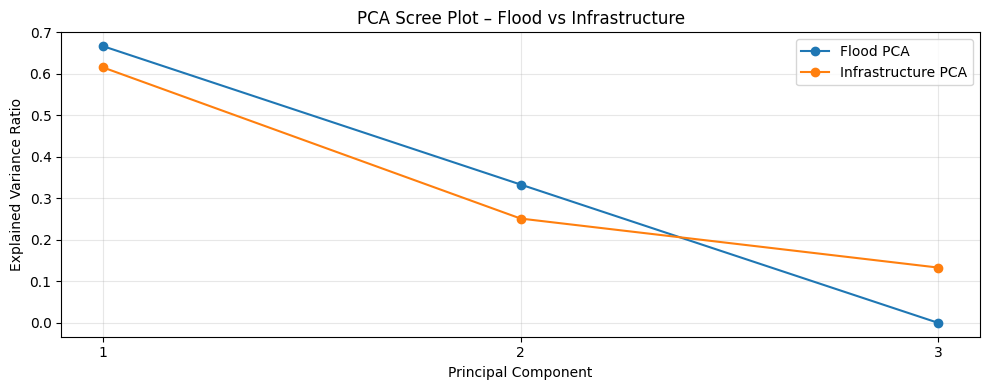

In [47]:
# ==============================
# Combined Scree Plot – Flood & Infrastructure PCA
# ==============================

import matplotlib.pyplot as plt
import pandas as pd

# Extract explained variance ratios
flood_var = flood_pca_full.explained_variance_ratio_
infra_var = infra_pca_full.explained_variance_ratio_

print(flood_var)
print(infra_var)
# Create common x-axis
max_pcs = max(len(flood_var), len(infra_var))
pcs = range(1, max_pcs + 1)

plt.figure(figsize=(10,4))

plt.plot(
    range(1, len(flood_var) + 1),
    flood_var,
    marker="o",
    label="Flood PCA"
)

plt.plot(
    range(1, len(infra_var) + 1),
    infra_var,
    marker="o",
    label="Infrastructure PCA"
)

plt.title("PCA Scree Plot – Flood vs Infrastructure")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(pcs)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Save figure
plt.savefig("scree_plots.png", dpi=300)
plt.show()

In [34]:
# ==============================
# PCA for modelling (2 PCs only)
# ==============================

from sklearn.decomposition import PCA
import pandas as pd

# Fit 2-component PCA using the same scaled matrices you already computed
flood_pca = PCA(n_components=2)
flood_pcs = flood_pca.fit_transform(flood_scaled)

infra_pca = PCA(n_components=2)
infra_pcs = infra_pca.fit_transform(infra_scaled)

# ---- Create PCA score DataFrames (THIS is what was missing) ----
flood_pc_df = pd.DataFrame(
    flood_pcs,
    columns=["Flood_PC1", "Flood_PC2"],
    index=flood_data.index   # aligns to original rows used for flood PCA
)

infra_pc_df = pd.DataFrame(
    infra_pcs,
    columns=["Infra_PC1", "Infra_PC2"],
    index=infra_data.index   # aligns to original rows used for infra PCA
)

# ---- Attach PCs back to cleaned dataframe ----
df_pcs = df_clean.join(flood_pc_df).join(infra_pc_df)
print("df_pcs shape (same as cleaned):", df_pcs.shape)

display(df_pcs[["Flood_PC1","Flood_PC2","Infra_PC1","Infra_PC2"]].head(15))

df_pcs shape (same as cleaned): (642, 26)


,Flood_PC1,Flood_PC2,Infra_PC1,Infra_PC2
0,-0.745139,-0.250433,-1.146309,0.630738
1,-0.745139,-0.250433,-1.146309,0.630738
2,-0.745139,-0.250433,-1.146309,0.630738
3,-0.745139,-0.250433,-1.146309,0.630738
4,-0.745139,-0.250433,-1.146309,0.630738
5,-0.745139,-0.250433,-1.146309,0.630738
6,-0.745139,-0.250433,-1.146309,0.630738
22,1.527716,-0.235887,-1.894026,0.237274
23,1.527716,-0.235887,-1.894026,0.237274
24,1.527716,-0.235887,-1.894026,0.237274


                                             PC1       PC2
% of catchment in flood-risk zone       0.707092  0.004525
Road flood days per year               -0.006400  0.999980
% of road length flooded at least once  0.707092  0.004525
                                     PC1       PC2
Catchment area km2              0.531719  0.734803
Total road length in catchment  0.644045 -0.027921
% of minor roads               -0.549983  0.677706


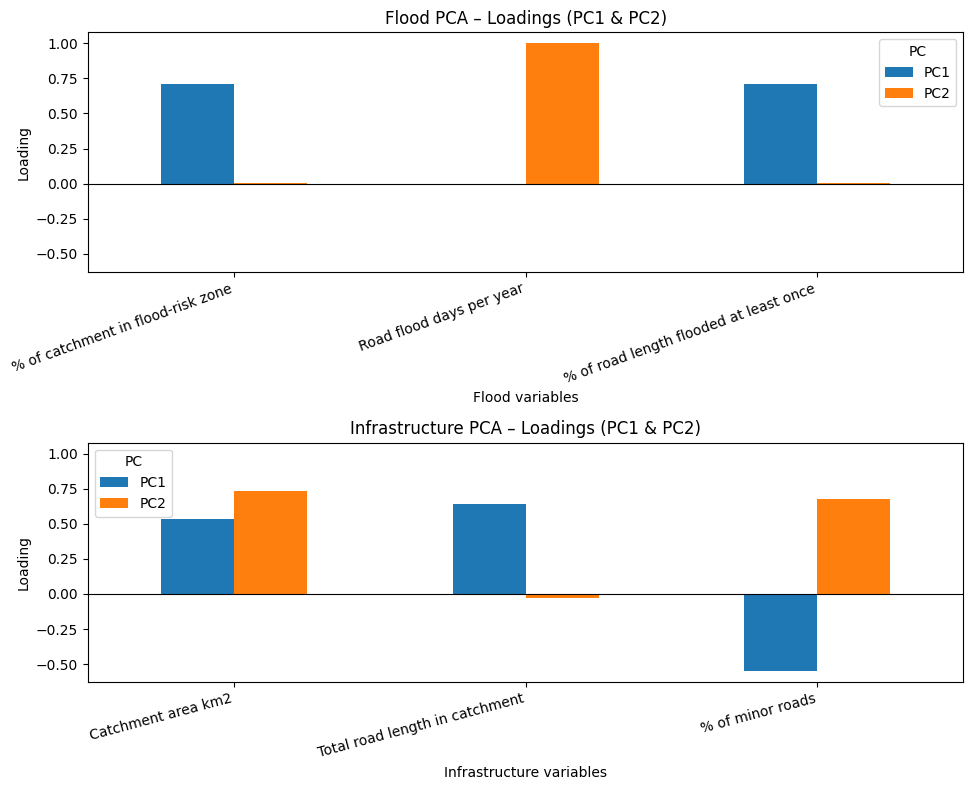

In [50]:
# ==============================
# PCA Loadings Plots (PC1 & PC2) – Combined Figure
# ==============================

import matplotlib.pyplot as plt
import pandas as pd

# Create loadings DataFrames
flood_loadings_2pc = pd.DataFrame(
    flood_pca.components_.T,
    index=flood_features,
    columns=["PC1", "PC2"]
)

infra_loadings_2pc = pd.DataFrame(
    infra_pca.components_.T,
    index=infra_features,
    columns=["PC1", "PC2"]
)

print(flood_loadings_2pc)
print(infra_loadings_2pc)

# Create subplots
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10,8),
    sharey=True
)

# ------------------------------
# Flood PCA loadings
# ------------------------------
flood_loadings_2pc.plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Flood PCA – Loadings (PC1 & PC2)")
axes[0].set_xlabel("Flood variables")
axes[0].set_ylabel("Loading")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].legend(title="PC")
plt.setp(axes[0].get_xticklabels(), rotation=20, ha="right")

# ------------------------------
# Infrastructure PCA loadings
# ------------------------------
infra_loadings_2pc.plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Infrastructure PCA – Loadings (PC1 & PC2)")
axes[1].set_xlabel("Infrastructure variables")
axes[1].set_ylabel("Loading")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].legend(title="PC")
plt.setp(axes[1].get_xticklabels(), rotation=15, ha="right")

# Layout + save
plt.tight_layout()
plt.savefig("pca_loadings_flood_infrastructure.png", dpi=300)
plt.show()

## 5) Modelling with PCs (Linear Regression and SVR)

We model the outcomes:
- `Absence rate`
- `Attainment score`
- `Year-on-year attainment`

Predictors:
- Flood_PC1, Flood_PC2, Infra_PC1, Infra_PC2

For each outcome we:
1. Create a complete-case modelling dataset (PCs + outcome)
2. Train/test split
3. Fit Linear Regression + report metrics + coefficient plot
4. Fit SVR (RBF) + report metrics + predicted vs actual plot



Outcome: Absence rate
Rows available for modelling: 607

--- Linear Regression ---
R²: 0.0648908338435168
RMSE: 1.0573433824716048


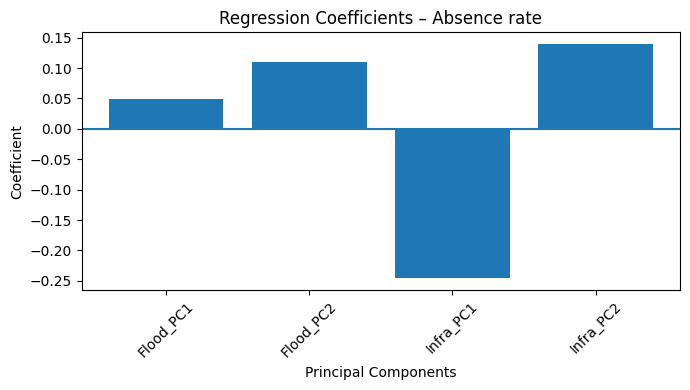


--- SVR (RBF) ---
R²: 0.05147979612899445
RMSE: 1.0648984318248427


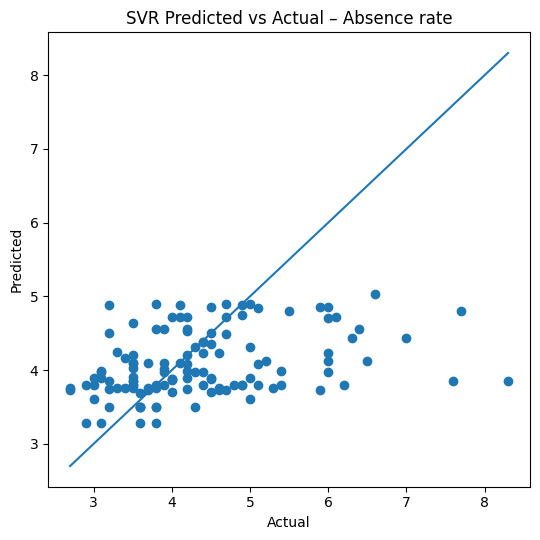


Outcome: Attainment score
Rows available for modelling: 628

--- Linear Regression ---
R²: 0.07523680357389328
RMSE: 19.437141319965335


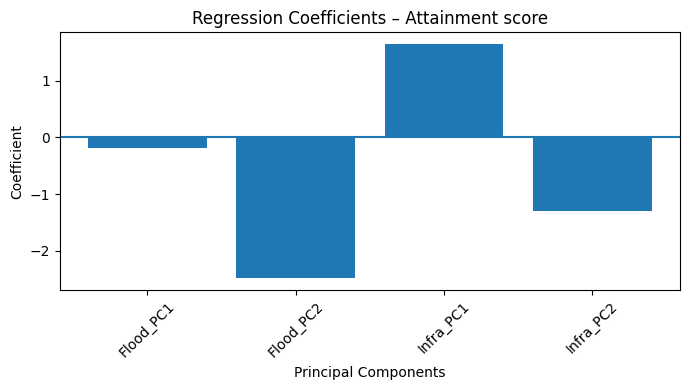


--- SVR (RBF) ---
R²: 0.030163795759731715
RMSE: 19.905189649832778


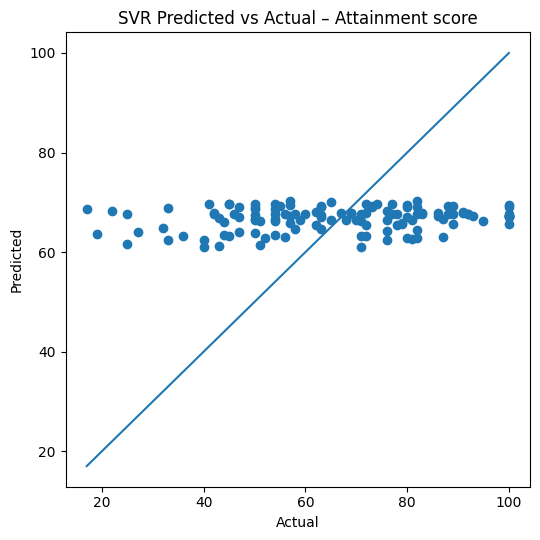


Outcome: Year-on-year attainment
Rows available for modelling: 475

--- Linear Regression ---
R²: -0.004418106626064011
RMSE: 59.90482170517955


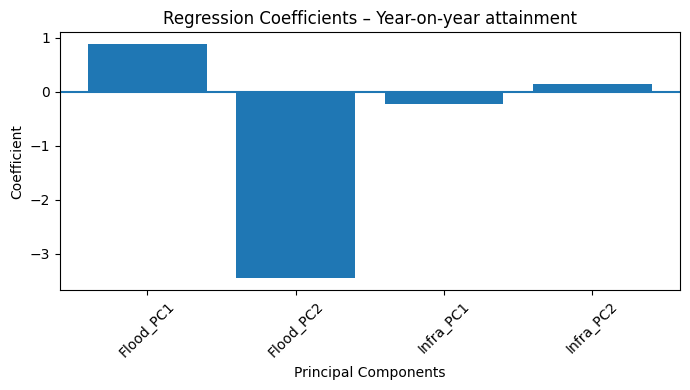


--- SVR (RBF) ---
R²: -0.038061727677049406
RMSE: 60.899833182502384


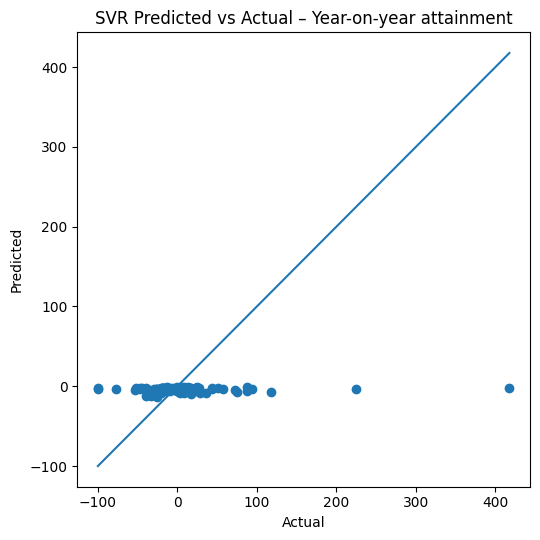

In [35]:

# ==============================
# 5) Regression + SVR
# ==============================

pc_features = ["Flood_PC1", "Flood_PC2", "Infra_PC1", "Infra_PC2"]
outcomes = ["Absence rate", "Attainment score", "Year-on-year attainment"]

# Ensure outcomes are numeric (in case some weren't percent-like)
for col in outcomes:
    if col in df_pcs.columns:
        df_pcs[col] = pd.to_numeric(df_pcs[col], errors="coerce")

def run_models(outcome):
    print("\n" + "="*60)
    print("Outcome:", outcome)
    print("="*60)

    model_data = df_pcs[pc_features + [outcome]].dropna()
    print("Rows available for modelling:", model_data.shape[0])

    if model_data.shape[0] < 30:
        print("⚠️ Very small sample size. Treat results as exploratory.")
    
    X = model_data[pc_features]
    y = model_data[outcome]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # -------- Linear Regression --------
    lin = LinearRegression()
    lin.fit(X_train, y_train)
    y_pred_lr = lin.predict(X_test)

    r2_lr = r2_score(y_test, y_pred_lr)
    rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

    print("\n--- Linear Regression ---")
    print("R²:", r2_lr)
    print("RMSE:", rmse_lr)

    coef_df = pd.DataFrame({"PC": pc_features, "Coefficient": lin.coef_}).set_index("PC")

    plt.figure(figsize=(7,4))
    plt.bar(coef_df.index, coef_df["Coefficient"])
    plt.axhline(0)
    plt.title(f"Regression Coefficients – {outcome}")
    plt.xlabel("Principal Components")
    plt.ylabel("Coefficient")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # -------- SVR (RBF) --------
    # Scale predictors for SVR
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    svr = SVR(kernel="rbf", C=1.0, epsilon=0.1)
    svr.fit(X_train_s, y_train)
    y_pred_svr = svr.predict(X_test_s)

    r2_svr = r2_score(y_test, y_pred_svr)
    rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))

    print("\n--- SVR (RBF) ---")
    print("R²:", r2_svr)
    print("RMSE:", rmse_svr)

    # Predicted vs actual
    plt.figure(figsize=(5.5,5.5))
    plt.scatter(y_test, y_pred_svr)
    min_val = min(y_test.min(), y_pred_svr.min())
    max_val = max(y_test.max(), y_pred_svr.max())
    plt.plot([min_val, max_val], [min_val, max_val])
    plt.title(f"SVR Predicted vs Actual – {outcome}")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.tight_layout()
    plt.show()


for outcome in outcomes:
    if outcome in df_pcs.columns:
        run_models(outcome)
    else:
        print(f"Outcome column not found: {outcome}")


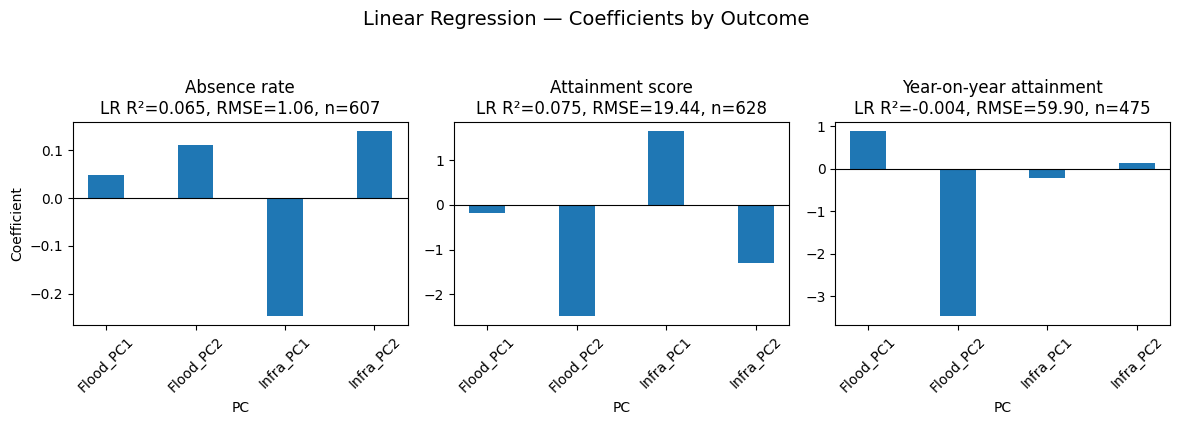

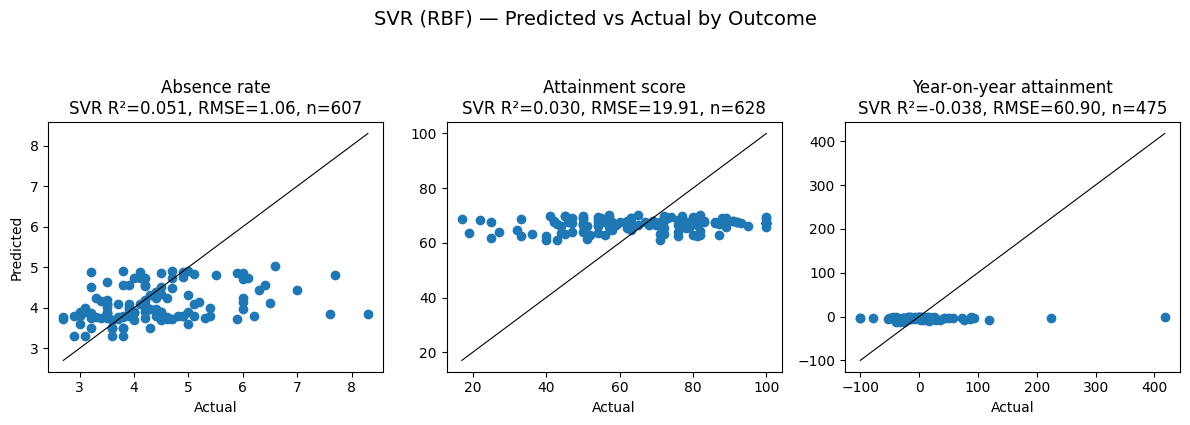

,Outcome,Rows_n,LR_R2,LR_RMSE,SVR_R2,SVR_RMSE
0,Absence rate,607,0.064891,1.057343,0.051480,1.064898
1,Attainment score,628,0.075237,19.437141,0.030164,19.905190
2,Year-on-year attainment,475,-0.004418,59.904822,-0.038062,60.899833


In [42]:
# ==============================
# 5) Regression + SVR (3 outcomes) — Combined subplot figures
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error

pc_features = ["Flood_PC1", "Flood_PC2", "Infra_PC1", "Infra_PC2"]
outcomes = ["Absence rate", "Attainment score", "Year-on-year attainment"]

# Ensure outcomes are numeric
for col in outcomes:
    if col in df_pcs.columns:
        df_pcs[col] = pd.to_numeric(df_pcs[col], errors="coerce")

fig_coef, axes_coef = plt.subplots(1, 3, figsize=(12, 4))
fig_svr, axes_svr = plt.subplots(1, 3, figsize=(12, 4))

# Track overall metrics
all_metrics = []

for i, outcome in enumerate(outcomes):
    ax_coef = axes_coef[i]
    ax_svr = axes_svr[i]

    if outcome not in df_pcs.columns:
        ax_coef.set_title(f"{outcome}\n(MISSING COLUMN)")
        ax_coef.axis("off")
        ax_svr.set_title(f"{outcome}\n(MISSING COLUMN)")
        ax_svr.axis("off")
        continue

    model_data = df_pcs[pc_features + [outcome]].dropna()
    n = model_data.shape[0]

    if n < 5:
        ax_coef.set_title(f"{outcome}\n(Too few rows: {n})")
        ax_coef.axis("off")
        ax_svr.set_title(f"{outcome}\n(Too few rows: {n})")
        ax_svr.axis("off")
        continue

    X = model_data[pc_features]
    y = model_data[outcome]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # --------------------------
    # Linear Regression
    # --------------------------
    lin = LinearRegression()
    lin.fit(X_train, y_train)
    y_pred_lr = lin.predict(X_test)

    r2_lr = r2_score(y_test, y_pred_lr)
    rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

    coef_df = pd.DataFrame({"PC": pc_features, "Coefficient": lin.coef_})

    ax_coef.bar(
        coef_df["PC"],
        coef_df["Coefficient"],
        width=0.4   # try 0.5–0.8
    )
    ax_coef.axhline(0, color="black", linewidth=0.8)
    ax_coef.set_title(f"{outcome}\nLR R²={r2_lr:.3f}, RMSE={rmse_lr:.2f}, n={n}")
    ax_coef.set_xlabel("PC")
    if i == 0:
        ax_coef.set_ylabel("Coefficient")
    ax_coef.tick_params(axis="x", rotation=45)

    # --------------------------
    # SVR (RBF)
    # --------------------------
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    svr = SVR(kernel="rbf", C=1.0, epsilon=0.1)
    svr.fit(X_train_s, y_train)
    y_pred_svr = svr.predict(X_test_s)

    r2_svr = r2_score(y_test, y_pred_svr)
    rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))

    ax_svr.scatter(y_test, y_pred_svr)
    min_val = min(y_test.min(), y_pred_svr.min())
    max_val = max(y_test.max(), y_pred_svr.max())
    ax_svr.plot([min_val, max_val], [min_val, max_val], color="black", linewidth=0.8)

    ax_svr.set_title(f"{outcome}\nSVR R²={r2_svr:.3f}, RMSE={rmse_svr:.2f}, n={n}")
    ax_svr.set_xlabel("Actual")
    if i == 0:
        ax_svr.set_ylabel("Predicted")

    all_metrics.append({
        "Outcome": outcome,
        "Rows_n": n,
        "LR_R2": r2_lr,
        "LR_RMSE": rmse_lr,
        "SVR_R2": r2_svr,
        "SVR_RMSE": rmse_svr
    })

# Finalise and save figures
fig_coef.suptitle("Linear Regression — Coefficients by Outcome", y=1.05, fontsize=14)
fig_coef.tight_layout()
fig_coef.savefig("linear_regression_coefficients_1x3.png", dpi=300)

fig_svr.suptitle("SVR (RBF) — Predicted vs Actual by Outcome", y=1.05, fontsize=14)
fig_svr.tight_layout()
fig_svr.savefig("svr_predicted_vs_actual_1x3.png", dpi=300)

plt.show()

# Optional: show a summary metrics table
metrics_df = pd.DataFrame(all_metrics)
display(metrics_df)

## Notes / Next steps
- If you end up with very few modelling rows, rerun the printed row counts and check which columns drive missingness.
- You can add diagnostics (missingness tables, distributions) before deciding whether to impute or drop.
